(5572, 2)
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Distribution des classes :
label
ham     4825
spam     747
Name: count, dtype: int64


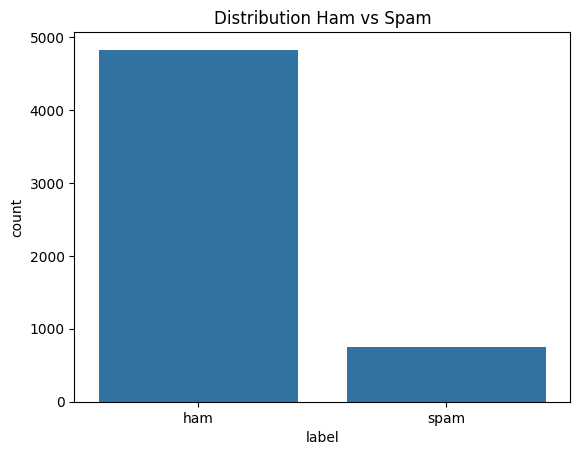

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


In [2]:
# ============================================================
# ÉTAPE 1 — Import & exploration des données
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement (encoding latin-1 souvent nécessaire pour ce dataset)
df = pd.read_csv("/content/spam.csv", encoding="latin-1", usecols=[0, 1])
df.columns = ["label", "text"]

# Aperçu
print(df.shape)
print(df.head())
print("\nDistribution des classes :")
print(df["label"].value_counts())

# Visualisation
sns.countplot(x="label", data=df)
plt.title("Distribution Ham vs Spam")
plt.show()

# Longueur des messages
df["text_length"] = df["text"].apply(len)
df.groupby("label")["text_length"].describe()

In [3]:
# ============================================================
# ÉTAPE 2 — Preprocessing NLP
# ============================================================

import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# --- 1. Encodage des labels ---
df["label_enc"] = df["label"].map({"ham": 0, "spam": 1})

# --- 2. Nettoyage du texte ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # supprime URLs
    text = re.sub(r"\d+", "", text)               # supprime chiffres
    text = re.sub(r"[^\w\s]", "", text)           # supprime ponctuation
    text = text.strip()
    return text

df["text_clean"] = df["text"].apply(clean_text)

# --- 3. Split train / test ---
X_train, X_test, y_train, y_test = train_test_split(
    df["text_clean"], df["label_enc"],
    test_size=0.2, random_state=42, stratify=df["label_enc"]
)

print(f"Train : {len(X_train)} | Test : {len(X_test)}")

# --- 4. Tokenisation ---
VOCAB_SIZE = 10000
MAX_LEN = 150   # longueur max d'un SMS en tokens

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)   # on fit UNIQUEMENT sur le train

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# --- 5. Padding (égalise la longueur de toutes les séquences) ---
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"Shape train : {X_train_pad.shape}")
print(f"Shape test  : {X_test_pad.shape}")

# Vérification sur un exemple
print("\nExemple SMS original :", X_train.iloc[0])
print("Après nettoyage :", df.loc[X_train.index[0], "text_clean"])
print("Séquence tokenisée (10 premiers tokens) :", X_train_seq[0][:10])

Train : 4457 | Test : 1115
Shape train : (4457, 150)
Shape test  : (1115, 150)

Exemple SMS original : going on nothing greatbye
Après nettoyage : going on nothing greatbye
Séquence tokenisée (10 premiers tokens) : [73, 19, 308, 3450]


In [4]:
# ============================================================
# ÉTAPE 3 — Modèle 1 : Embedding + réseau dense (baseline)
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# --- Gestion du déséquilibre des classes (4825 ham vs 747 spam) ---
total = len(y_train)
n_spam = y_train.sum()
n_ham  = total - n_spam
class_weight = {0: 1.0, 1: n_ham / n_spam}
print(f"Poids classe spam : {class_weight[1]:.2f}")

# --- Architecture ---
EMBEDDING_DIM = 32

model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")   # sortie binaire : ham=0 / spam=1
])

model1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model1.summary()

# --- Entraînement ---
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history1 = model1.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Poids classe spam : 6.45


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8190 - loss: 1.1918 - val_accuracy: 0.8453 - val_loss: 0.6731
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7093 - loss: 1.1739 - val_accuracy: 0.8453 - val_loss: 0.5723
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8257 - loss: 1.0549 - val_accuracy: 0.9238 - val_loss: 0.5687
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8988 - loss: 0.6973 - val_accuracy: 0.9462 - val_loss: 0.2170
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9579 - loss: 0.4060 - val_accuracy: 0.9552 - val_loss: 0.2619
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9616 - loss: 0.3019 - val_accuracy: 0.9664 - val_loss: 0.1279
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9619 - loss: 0.2507 - val_accuracy: 0.9596 - val_loss: 0.1078
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9706 - loss: 0.2207 - val_accuracy: 0

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
=== Modèle 1 : Embedding + Dense ===
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.96      0.88      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



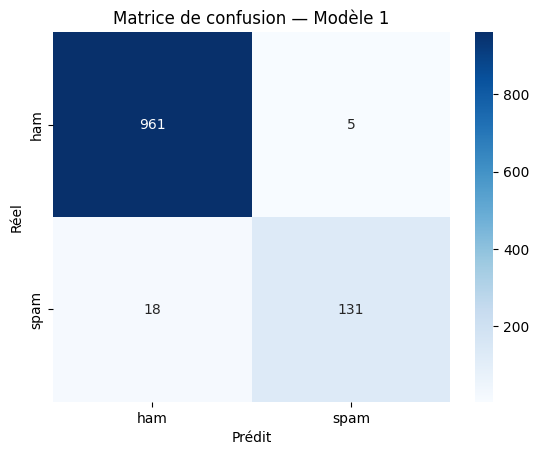

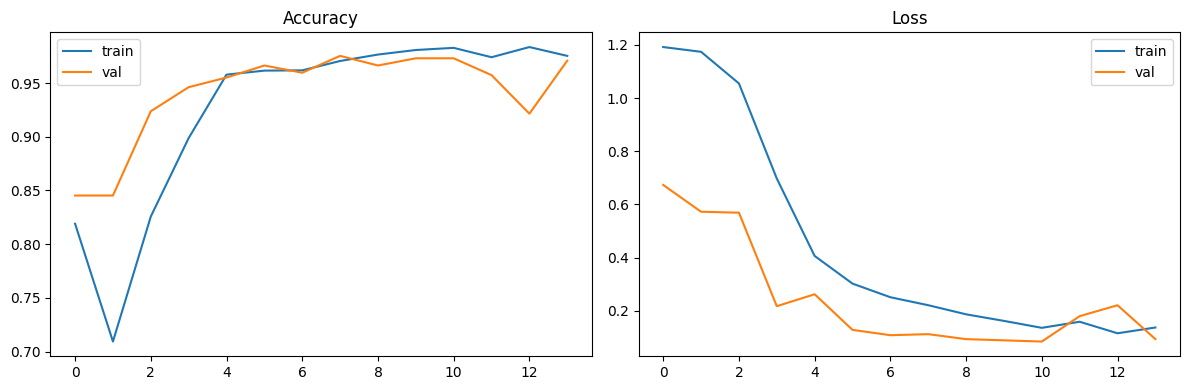

In [5]:
# ============================================================
# ÉTAPE 4 — Évaluation Modèle 1
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Prédictions ---
y_pred_prob1 = model1.predict(X_test_pad)
y_pred1 = (y_pred_prob1 > 0.5).astype(int).flatten()

# --- Rapport de classification ---
print("=== Modèle 1 : Embedding + Dense ===")
print(classification_report(y_test, y_pred1, target_names=["ham", "spam"]))

# --- Matrice de confusion ---
cm1 = confusion_matrix(y_test, y_pred1)
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"])
plt.title("Matrice de confusion — Modèle 1")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()

# --- Courbes d'apprentissage ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history1.history["accuracy"], label="train")
ax1.plot(history1.history["val_accuracy"], label="val")
ax1.set_title("Accuracy")
ax1.legend()

ax2.plot(history1.history["loss"], label="train")
ax2.plot(history1.history["val_loss"], label="val")
ax2.set_title("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# ÉTAPE 5 — Modèle 2 : Transfer Learning (DistilBERT HuggingFace)
# ============================================================

!pip install transformers torch -q

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# --- Tokenizer ---
bert_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_bert(texts, max_len=128):
    return bert_tokenizer(
        list(texts),
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

print("Tokenisation...")
train_enc = tokenize_bert(X_train.values)
test_enc  = tokenize_bert(X_test.values)

# --- Dataset PyTorch ---
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long)

train_dataset = TensorDataset(train_enc["input_ids"], train_enc["attention_mask"], y_train_t)
test_dataset  = TensorDataset(test_enc["input_ids"],  test_enc["attention_mask"],  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)

# --- Modèle ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

model2 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).to(device)

# --- Entraînement (2 epochs suffisent) ---
from torch.optim import AdamW

optimizer = AdamW(model2.parameters(), lr=2e-5)

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for input_ids, attention_mask, labels in loader:
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        optimizer.step()
        total_loss += outputs.loss.item()
        correct += (outputs.logits.argmax(dim=1) == labels).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

print("Entraînement DistilBERT...")
for epoch in range(2):
    loss, acc = train_epoch(model2, train_loader, optimizer)
    print(f"Epoch {epoch+1}/2 — loss: {loss:.4f} — accuracy: {acc:.4f}")

print("Terminé !")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenisation...
Device : cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Entraînement DistilBERT...
Epoch 1/2 — loss: 0.1459 — accuracy: 0.9524
Epoch 2/2 — loss: 0.0394 — accuracy: 0.9904
Terminé !


=== Modèle 2 : DistilBERT (Transfer Learning) ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.96      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.98      0.97      1115
weighted avg       0.99      0.99      0.99      1115



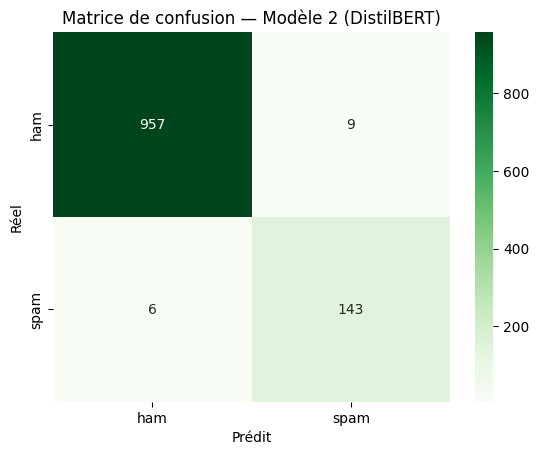


========== COMPARAISON DES MODÈLES ==========
Modèle                                Accuracy    F1 spam
---------------------------------------------------------
Embedding + Dense (baseline)             0.979      0.919
DistilBERT (transfer learning)           0.987      0.950


In [7]:
# ============================================================
# ÉTAPE 6 — Évaluation Modèle 2 + Comparaison
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Prédictions DistilBERT ---
model2.eval()
all_preds = []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        outputs = model2(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

y_pred2 = np.array(all_preds)

# --- Rapport ---
print("=== Modèle 2 : DistilBERT (Transfer Learning) ===")
print(classification_report(y_test, y_pred2, target_names=["ham", "spam"]))

# --- Matrice de confusion ---
cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens",
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"])
plt.title("Matrice de confusion — Modèle 2 (DistilBERT)")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()

# --- Tableau comparatif ---
print("\n========== COMPARAISON DES MODÈLES ==========")
print(f"{'Modèle':<35} {'Accuracy':>10} {'F1 spam':>10}")
print("-" * 57)
from sklearn.metrics import f1_score, accuracy_score
print(f"{'Embedding + Dense (baseline)':<35} {accuracy_score(y_test, y_pred1):>10.3f} {f1_score(y_test, y_pred1):>10.3f}")
print(f"{'DistilBERT (transfer learning)':<35} {accuracy_score(y_test, y_pred2):>10.3f} {f1_score(y_test, y_pred2):>10.3f}")

## Conclusion

### Résultats obtenus

Deux modèles de deep learning ont été entraînés pour détecter les SMS spam :

**Modèle 1 — Embedding + Dense (baseline)**
- Architecture légère : couche Embedding (32 dims) + GlobalAveragePooling + Dense
- Accuracy : 97.9% | F1 spam : 0.919
- Entraîné en ~10 secondes sur CPU

**Modèle 2 — DistilBERT (Transfer Learning)**
- Modèle pré-entraîné sur des milliards de tokens (HuggingFace)
- Fine-tuné en 2 epochs seulement grâce au transfer learning
- Accuracy : 98.7% | F1 spam : 0.950
- Entraîné en ~1 minute sur GPU T4

### Analyse

Le transfer learning avec DistilBERT apporte un gain clair sur la détection des spams
(F1 : +3.1 points), particulièrement sur le recall spam (0.96 vs 0.84),
ce qui signifie moins de spams non détectés.

Le modèle baseline reste compétitif compte tenu de sa simplicité —
il constitue une solution efficace quand les ressources de calcul sont limitées.

### Choix du modèle recommandé

DistilBERT est recommandé en production pour AT&T :
sa meilleure détection des spams justifie le coût computationnel supplémentaire.